# AI Model Experiment & Evaluation
**Starter Notebook**

Notebook ini adalah kerangka awal untuk membandingkan dua pendekatan AI dalam menyelesaikan task sentiment analysis ulasan pelanggan:
1. Model klasik Machine Learning (Scikit-learn)
2. LLM API (Gemini)

Isi tiap section sesuai instruksi di Assignment Brief. Jangan ubah struktur section, tapi silakan tambah cell baru di dalam tiap section jika diperlukan.

> 🔧 **Catatan Penyesuaian Dataset**
>
> Notebook ini menggunakan dataset `customer_reviews_sentiment.csv` dengan kolom `review_text` dan `sentiment` (nilai: `positif`/`negatif`).
>
> Apabila dataset final berbeda dari yang digunakan saat ini, sesuaikan bagian berikut:
> - Nama file pada `pd.read_csv(...)` di Section 2
> - Nama kolom teks dan label pada Section 3 (saat ini: `review_text`, `sentiment`)
> - Label yang diminta pada prompt LLM di Section 5.2 (saat ini: `positif`/`negatif`)
> - Studi Kasus pada Assignment Brief, apabila domain data berbeda dari e-commerce

## 1. Problem Statement

**Objective:** Tim produk e-commerce ingin fitur otomatis pengklasifikasi sentimen ulasan pelanggan (positif/negatif) di halaman produk. Eksperimen ini membandingkan dua kandidat pendekatan &mdash; model klasik (Scikit-learn) dan LLM via Gemini API &mdash; pada test set yang sama, sebagai rekomendasi technical approach.

**Target/label:** kolom `sentiment`, dua kelas: positif (110) dan `negatif` (90) dari total 200 ulasan. Input: teks ulasan pada kolom `review_text`.

**Batasan/asumsi:**
1. hanya klasifikasi biner &mdash; dataset tidak memuat kelas netral.
2. label `sentiment` dianggap ground truth.
3. dataset asli tidak diubah sama sekali.
4. kedua pendekatan mengevaluasi test set yang identik (20% data, stratified, `random_state=42`).
5. LLM tidak dilatih ulang, hanya prompting. 

## 2. Import Library & Load Dataset

In [1]:
# 🔧 Sesuaikan nama file jika dataset final berbeda
import os
import time

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from google import genai  # library resmi Gemini API (paket google-genai)
from google.genai import types
from dotenv import load_dotenv

# GEMINI_API_KEY dibaca dari environment proses kernel. Tanpa dotenv kode tetap
# jalan selama variabel sudah di-export di shell, tapi load_dotenv() membuat
# notebook self-contained: otomatis memuat file .env di folder project.
load_dotenv()

df = pd.read_csv('../data/customer_reviews_sentiment.csv')
print(df.shape)
df.head()


(200, 4)


,review_id,product_name,review_text,sentiment
0,1,Kemeja Flanel,Pelayanan lambat dan tidak responsif saat diko...,negatif
1,2,Case HP,"Puas banget belanja disini, proses cepat dan b...",positif
2,3,Rice Cooker,"Terima kasih seller, barangnya awet dan sesuai...",positif
3,4,Case HP,Warna produk berbeda jauh dari foto di listing.,negatif
4,5,Headset Bluetooth,"Terima kasih seller, barangnya awet dan sesuai...",positif


In [2]:
# Profil dataset: keseimbangan kelas, keunikan teks, dan kelengkapan data.
# 40 teks unik dari 200 baris = ulasan berpola template — penting untuk analisis Section 7.
print(df['sentiment'].value_counts())
print('-' * 40)
print('Teks unik:', df['review_text'].nunique(), 'dari', len(df), 'baris')
print('-' * 40)
print('Missing values:', df.isnull().sum().sum())


sentiment
positif    110
negatif     90
Name: count, dtype: int64
----------------------------------------
Teks unik: 40 dari 200 baris
----------------------------------------
Missing values: 0


## 3. Menyiapkan Train/Test Split

Pastikan test set yang sama digunakan untuk kedua pendekatan agar perbandingan adil.

In [3]:
# 🔧 Sesuaikan nama kolom jika dataset final menggunakan nama kolom berbeda
X = df['review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 160
Test size: 40


## 4. Pendekatan 1 — Model Klasik (Scikit-learn)

### 4.1 Preprocessing & Feature Extraction

In [4]:
# ngram_range=(1, 2): menyertakan frasa dua kata (mis. "tidak sesuai", "sangat kecewa")
# agar konteks negasi tidak hilang saat teks dipecah per kata.
# Pada dataset berpola template ini unigram saja sudah cukup (lihat Section 6);
# bigram ditambahkan sebagai ketahanan terhadap ulasan dengan pola baru.
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


### 4.2 Training Model

In [5]:
# max_iter=1000: default LogisticRegression hanya 100 iterasi; pada fitur TF-IDF
# berdimensi tinggi optimasi kadang belum konvergen (ConvergenceWarning).
# 1000 memberi ruang ekstra agar pelatihan selesai secara konvergen.
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

### 4.3 Prediksi pada Test Set

In [6]:
y_pred_classic = clf.predict(X_test_vec)

## 5. Pendekatan 2 — LLM API (Gemini)

### 5.1 Setup API

In [7]:
# Simpan API key di environment variable, JANGAN hardcode langsung di notebook
client = genai.Client(api_key=os.environ.get('GEMINI_API_KEY'))

### 5.2 Merancang Prompt

_Tuliskan prompt yang kamu rancang di sini, dan jelaskan alasannya (zero-shot / few-shot)._

In [8]:
def classify_sentiment_llm(review_text):
    # Few-shot: dua contoh memperjelas "kontrak output" ke LLM — jawaban harus
    # tepat satu kata dan hanya boleh positif/negatif — sehingga format jawaban
    # lebih konsisten dibanding zero-shot murni.
    prompt = f'''Kamu adalah pengklasifikasi sentimen ulasan pelanggan e-commerce.
Klasifikasikan ulasan berikut ke satu label: "positif" atau "negatif".

Contoh:
Ulasan: "Barang datang cepat, kualitas bagus, sangat puas."
Sentimen: positif
Ulasan: "Barang rusak dan packing berantakan, sangat kecewa."
Sentimen: negatif

Ulasan: "{review_text}"
Sentimen:'''

    for attempt in range(5):
        try:
            # gemini-3.5-flash-lite: varian termurah & tercepat di keluarga Gemini,
            # kapasitasnya lebih dari cukup untuk klasifikasi biner sederhana.
            # Free tier dibatasi 15 request/menit per model — ditangani retry
            # di bawah plus jeda 4.5 detik pada loop prediksi.
            response = client.models.generate_content(
                model='gemini-3.5-flash-lite',
                contents=prompt,
                config=types.GenerateContentConfig(temperature=0.0),
            )
            return response.text
        except Exception as e:
            if '429' in str(e) and attempt < 4:
                wait = 15 * (attempt + 1)
                print(f'Rate limit, menunggu {wait} detik...')
                time.sleep(wait)
            else:
                raise


### 5.3 Menjalankan Prediksi pada Test Set

Catatan: lakukan normalisasi terhadap output LLM sebelum dibandingkan dengan label asli (misal: lowercase, strip whitespace).

In [9]:
def normalize_label(raw):
    text = raw.strip().lower()
    if 'pos' in text:
        return 'positif'
    if 'neg' in text:
        return 'negatif'
    return 'tidak_valid'

y_pred_llm = []
pred_cache = {}  # simpan hasil per teks ulasan

for review in X_test:
        if review not in pred_cache:
            pred_cache[review] = normalize_label(classify_sentiment_llm(review))
            time.sleep(4.5)  # ~13 request/menit, di bawah limit 15
        y_pred_llm.append(pred_cache[review])

pd.Series(y_pred_llm).value_counts()

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


positif    22
negatif    18
Name: count, dtype: int64

## 6. Evaluasi dan Perbandingan

### 6.1 Evaluasi Model Klasik

In [10]:
print('=== Model Klasik (TF-IDF + Logistic Regression) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_classic))
print(classification_report(y_test, y_pred_classic))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_classic))


=== Model Klasik (TF-IDF + Logistic Regression) ===
Accuracy: 1.0
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.2 Evaluasi LLM API

In [11]:
print('=== LLM API (Gemini) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_llm))
print(classification_report(y_test, y_pred_llm))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_llm))

=== LLM API (Gemini) ===
Accuracy: 1.0
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.3 Tabel Perbandingan Ringkasan

_Susun tabel ringkasan (bisa markdown table atau DataFrame) yang membandingkan Accuracy, Precision, Recall, F1-Score kedua pendekatan._

In [12]:
# Tabel ringkasan perbandingan metrik kedua pendekatan pada test set yang sama.
# average='macro': kedua kelas diberi bobot sama tanpa memandang jumlah datanya
# (positif 22 vs negatif 18) — cocok untuk kelas yang sedikit tidak seimbang.
# zero_division=0: cegah warning bila ada kelas yang tak pernah diprediksi.
def metrics_row(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'Pendekatan': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (macro)': round(p, 4),
        'Recall (macro)': round(r, 4),
        'F1-Score (macro)': round(f1, 4),
    }

comparison = pd.DataFrame([
    metrics_row('Model Klasik (Scikit-learn)', y_test, y_pred_classic),
    metrics_row('LLM API (Gemini)', y_test, y_pred_llm),
])
comparison


,Pendekatan,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,Model Klasik (Scikit-learn),1.0,1.0,1.0,1.0
1,LLM API (Gemini),1.0,1.0,1.0,1.0


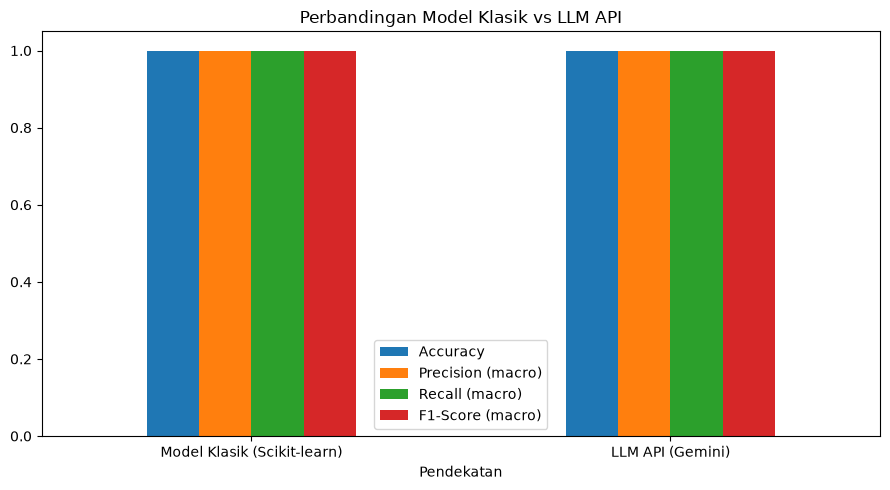

In [13]:
# Visualisasi tabel perbandingan; disimpan ke documentation/ sebagai
# deliverable opsional (model_comparison_summary.png).
import matplotlib.pyplot as plt

comparison.set_index('Pendekatan').plot(kind='bar', figsize=(9, 5), rot=0)
plt.title('Perbandingan Model Klasik vs LLM API')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../documentation/model_comparison_summary.png', dpi=150)
plt.show()


## 7. Analisis Trade-off dan Limitation

_Tuliskan analisis: pendekatan mana yang lebih unggul dari sisi performa, trade-off effort/kecepatan/biaya, dan keterbatasan masing-masing pendekatan._

- **Performa:** keduanya sempurna di test set yang sama — Accuracy, Precision, Recall, dan F1-Score (macro) semuanya **1.0** untuk model klasik maupun LLM API. Tidak ada pemenang dari sisi metrik; keputusan bergantung pada faktor non-akurasi di bawah.
- **Effort implementasi:** klasik butuh preprocessing + training + tuning; LLM tanpa training, cukup desain prompt — waktu implementasi jauh lebih singkat.
- **Kecepatan:** klasik — train + prediksi berjalan hitungan detik lokal; LLM — 40 panggilan API berurutan dengan jeda 4.5 detik antar-panggilan (sekitar 3 menit), jauh lebih lambat.
- **Biaya:** klasik gratis di lokal; LLM berbayar per token — kecil untuk 40 ulasan, tapi signifikan jika diskalakan ke jutaan ulasan produksi.
- **Limitasi model klasik:** hanya mengenali kosakata/frasa dari data training; tidak memahami konteks, negasi kompleks, atau sarkasme; perlu retraining jika pola ulasan berubah.
- **Limitasi LLM:** output teks bebas perlu dinormalisasi; dependensi jaringan + latensi + risiko rate limit; kirim data pelanggan ke API pihak ketiga (privasi); potensi variasi output meski temperature rendah.
- **Catatan kritis dataset:** dari 200 ulasan hanya ada 40 teks unik — ulasan berpola template. Dengan split acak, template yang sama muncul di train dan test, sehingga skor model klasik berpotensi **overestimate** dan tidak menggambarkan performa pada ulasan benar-benar baru. Hasil 1.0 kedua pendekatan pun harus dibaca dengan hati-hati karena alasan yang sama.


## 8. Rekomendasi Technical Approach

_Tuliskan rekomendasi akhir beserta alasannya, berdasarkan hasil eksperimen di atas._

Untuk use case ini, rekomendasi saya: **model klasik sebagai pendekatan utama** — performanya setara dengan LLM (F1 = 1.0 pada test set yang sama), tetapi biayanya nol, latensinya rendah (train + prediksi hitungan detik, tanpa panggilan jaringan), outputnya deterministik sehingga mudah direproduksi dan di-audit, dan data pelanggan tidak keluar dari sistem. LLM (Gemini) diposisikan sebagai pelengkap untuk kasus sulit/kategori baru, misal pola hybrid: model klasik memproses mayoritas ulasan, ulasan dengan confidence rendah dieskalasi ke LLM. Jika volume ulasan kecil dan kecepatan implementasi jadi prioritas utama, LLM API layak dipakai langsung dengan konsekuensi biaya per-token.


In [14]:
# TODO: review and compare notebook
# TODO: review for bootcamp notes